<a href="https://colab.research.google.com/github/RiyaDhami13/Student-Performance-Analyzer/blob/main/Student_Performance_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dskagglemt/student-performance-data-set")

print("Path to dataset files:", path)

100%|██████████| 21.6k/21.6k [00:00<00:00, 18.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dskagglemt/student-performance-data-set/versions/1


In [ ]:
#Theme setting
sns.set_theme(style="whitegrid",palette="deep")
plt.rcParams["figure.figsize"] = (8,5) #defines the default size for plt methods


In [ ]:
#The setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/dskagglemt/student-performance-data-set/versions/1/student-mat.csv"

df = pd.read_csv(path, sep=";")
print(df.shape)
print(df.head())

(395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [ ]:
#Basic info
print(df.info())
print(df.describe().T)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
# Dataset: 395 students, 33 features
# Average final grade: 10.4/20 — majority barely passing
# Max absences: 75 — extreme outlier exists
# No missing values — dataset is clean

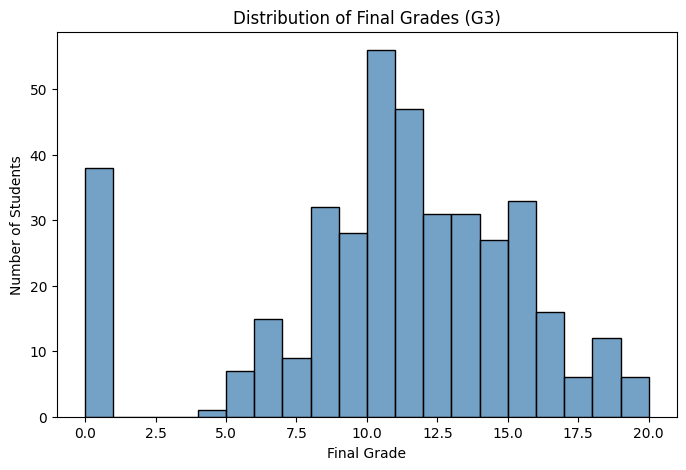

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["G3"], bins=20, color="steelblue")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
# G3 distribution shows:
# - Most students cluster around 10-12 (barely passing)
# - ~40 students scored 0 — likely dropouts or final exam absences
# - Very few students score above 18 — high achievers are rare

In [ ]:
print(df[df["G3"] == 0].shape[0])
print(df[df["G3"] > 0].shape[0])

38
357


In [ ]:
df_clean = df[df["G3"] > 0].copy()
print(df_clean.shape)

(357, 33)


In [ ]:
# Removed 38 students with G3 = 0 (likely dropouts/absent for final)
# Working dataset: 357 students
# Original dataset preserved in df

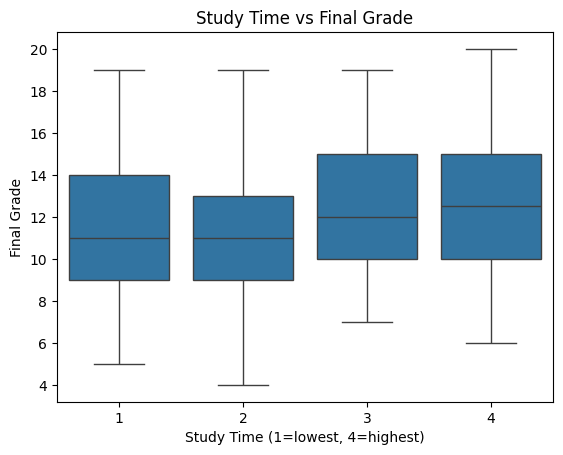

In [ ]:
sns.boxplot(x="studytime", y="G3", data=df_clean)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=lowest, 4=highest)")
plt.ylabel("Final Grade")
plt.show()

In [ ]:
# Study time vs G3:
# Weak positive relationship — more study = slightly higher median
# But huge overlap between groups
# Study time alone does not determine final grade
# Other factors must be involved

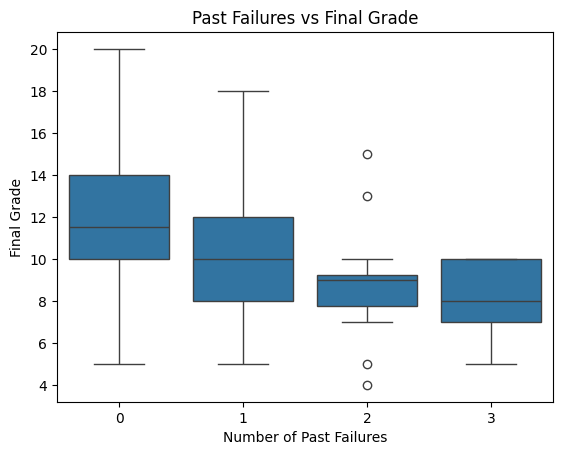

In [ ]:
sns.boxplot(x="failures", y="G3", data=df_clean)
plt.title("Past Failures vs Final Grade")
plt.xlabel("Number of Past Failures")
plt.ylabel("Final Grade")
plt.show()